# Isotropic damage in a plate with hole
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/basic/planar/damage.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/meyer-nils/torch-fem/main?labpath=examples/basic/planar/damage.ipynb)

A plate with a hole is stretched until a damage band forms across the ligament. The same problem is solved under plane stress and under plane strain, which restrains the out-of-plane contraction.

In [1]:
import matplotlib.pyplot as plt
import torch

from torchfem.data import get_data
from torchfem.io import import_mesh
from torchfem.materials import IsotropicDamagePlaneStrain, IsotropicDamagePlaneStress

torch.set_default_dtype(torch.float64)

## Damage law

The material is elastic up to an equivalent strain (the principal strain largest in magnitude) of $\varepsilon_0$, then softens exponentially. The fracture energy per unit area is

$$
G_\textrm{f} = l_\textrm{c} \int_{\varepsilon_0}^{\infty} \sigma d \varepsilon
$$

with the characteristic element length $l_c$, which regularizes the dissipated energy against the mesh. The [material documentation](https://meyer-nils.github.io/torch-fem/materials/damage/isotropic_damage_plane_stress/) states the stress, the equivalent strain and the algorithmic tangent.

In [2]:
# Elastic parameters (Young's modulus and Poisson's ratio)
E = 1000.0
nu = 0.3

# Damage parameters (damage initiation strain and fracture energy)
eps_0 = 4.0e-3
G_f = 2.0e-3


def d(kappa, cl):
    # Damage evolution law for exponential strain softening
    eps_f = G_f / (E * eps_0 * cl) + eps_0 / 2.0
    evolution = 1.0 - eps_0 / kappa * torch.exp(-(kappa - eps_0) / (eps_f - eps_0))
    evolution[kappa < eps_0] = 0.0

    return evolution


def d_prime(kappa, cl):
    # Derivative of the damage evolution law
    eps_f = G_f / (E * eps_0 * cl) + eps_0 / 2.0
    derivative = (
        eps_0
        * torch.exp(-(kappa - eps_0) / (eps_f - eps_0))
        * (1 / kappa**2 + 1 / (kappa * (eps_f - eps_0)))
    )
    derivative[kappa < eps_0] = 0.0

    return derivative

## Plane stress damage

#### Geometry
The mesh is imported from the example files. The left edge is clamped and the right edge is pulled in the 1-direction with a displacement boundary condition, so the softening branch stays stable.

In [3]:
material = IsotropicDamagePlaneStress(E, nu, d, d_prime, "rankine")

# Dimensions (thickness of plate t and edge length L)
t = 0.01
L = 0.2

# Applied displacement
u_max = 1.5e-3

# Import mesh
plate = import_mesh(get_data("plate_hole.vtk"), material, thickness=t)

# Fixed boundary at left end
plate.constraints[plate.nodes[:, 0] < 1e-6] = True

# Prescribed displacement at right end
right = plate.nodes[:, 0] > L - 1e-6
plate.constraints[right, 0] = True
plate.displacements[right, 0] = u_max

# Increments
increments = torch.linspace(0.0, 1.0, 60)

#### Solve

In [4]:
u, f, _, _, alpha = plate.solve(increments=increments, return_intermediate=True)

#### Postprocessing
Damage initiates at the hole, where the strain concentrates, and grows into a band across the ligament.

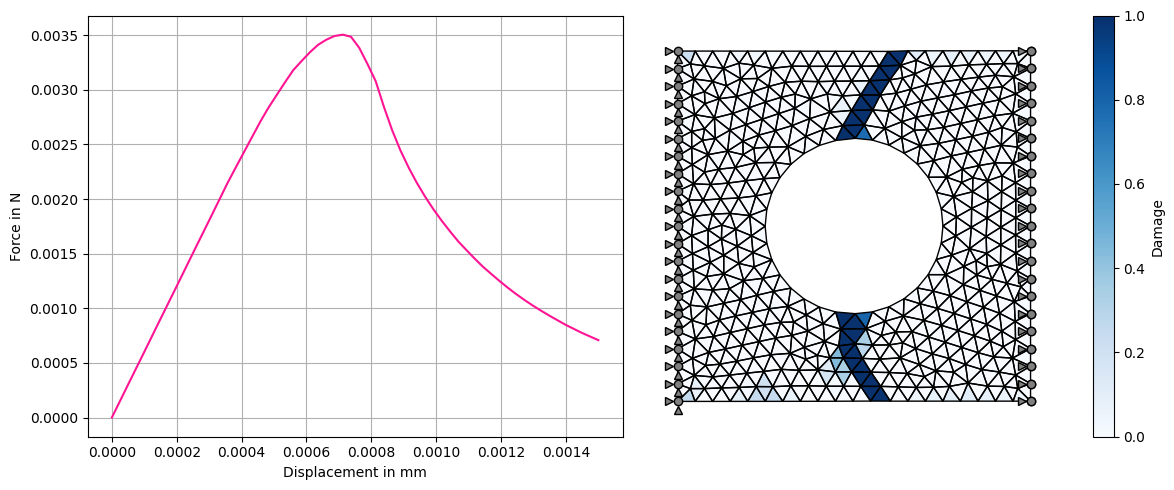

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(
    u[:, right, 0].mean(dim=-1), f[:, right, 0].sum(dim=-1), "-", color="deeppink"
)
ax[0].set_xlabel("Displacement in mm")
ax[0].set_ylabel("Force in N")
ax[0].grid()

plate.plot(
    u=u[-1],
    element_property={"Damage": alpha[-1, :, 1]},
    cmap="Blues",
    vmin=0.0,
    vmax=1.0,
    colorbar=True,
    ax=ax[1],
)
plt.tight_layout()
plt.show()

## Plane strain damage

#### Geometry
The same plate and boundary conditions, with the out-of-plane strain suppressed instead of the out-of-plane stress.

In [6]:
material = IsotropicDamagePlaneStrain(E, nu, d, d_prime, "rankine")

# Dimensions (thickness of plate t and edge length L)
t = 0.01
L = 0.2

# Applied displacement
u_max = 1.5e-3

# Import mesh
plate = import_mesh(get_data("plate_hole.vtk"), material, thickness=t)

# Fixed boundary at left end
plate.constraints[plate.nodes[:, 0] < 1e-6] = True

# Prescribed displacement at right end
right = plate.nodes[:, 0] > L - 1e-6
plate.constraints[right, 0] = True
plate.displacements[right, 0] = u_max

# Increments
increments = torch.linspace(0.0, 1.0, 60)

#### Solve

In [7]:
u, f, _, _, alpha = plate.solve(increments=increments, return_intermediate=True)

#### Postprocessing
The suppressed out-of-plane contraction stiffens the plate, so it carries a higher peak load before the band forms.

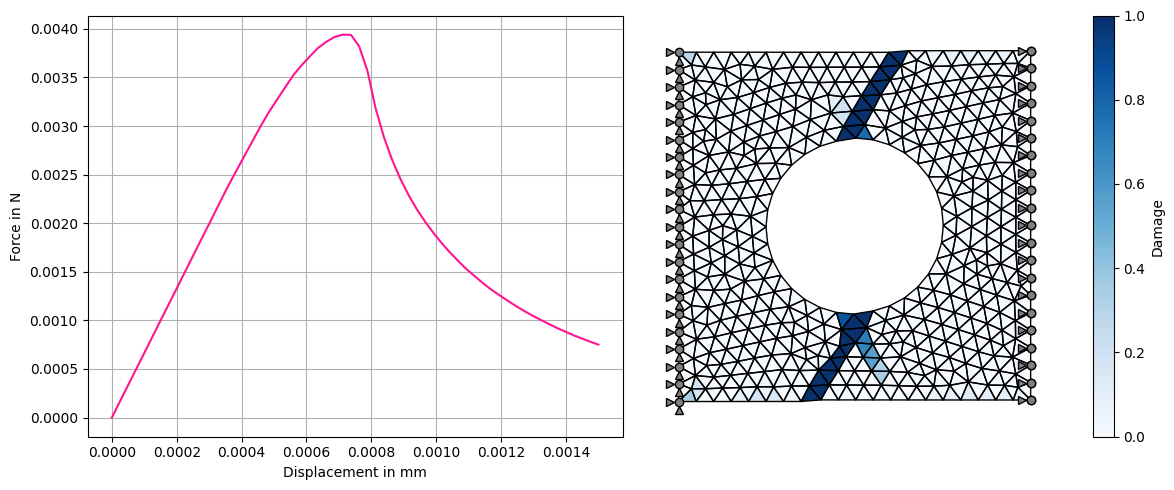

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(
    u[:, right, 0].mean(dim=-1), f[:, right, 0].sum(dim=-1), "-", color="deeppink"
)
ax[0].set_xlabel("Displacement in mm")
ax[0].set_ylabel("Force in N")
ax[0].grid()

plate.plot(
    u=u[-1],
    element_property={"Damage": alpha[-1, :, 1]},
    cmap="Blues",
    vmin=0.0,
    vmax=1.0,
    colorbar=True,
    ax=ax[1],
)
plt.tight_layout()
plt.show()